In [1]:
# ==========================================
# STEP 1 : Import Required Libraries
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# STEP 2 : Load Raw Dataset
# ==========================================

df = pd.read_csv("../data/cars_data_clean.csv")

print(df.shape)

df.head()

(37813, 66)


,usedCarSkuId,loc,myear,body,transmission,fuel,km,ip,images,imgCount,...,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,Bore,Stroke
0,7111bf25-97af-47f9-867b-40879190d800,gomti nagar,2016,hatchback,manual,cng,69162.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,...,NaN,NaN,NaN,NaN,58.16,6200.0,77.0,3500.0,69.0,NaN
1,c309efc1-efaf-4f82-81ad-dcb38eb36665,borivali west,2015,hatchback,manual,cng,45864.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,...,Gasoline Port Injection,11.0,NaN,NaN,58.20,6000.0,78.0,3500.0,73.0,NaN
2,7609f710-0c97-4f00-9a47-9b9284b62d3a,jasola,2015,sedan,manual,cng,81506.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,...,NaN,NaN,NaN,NaN,86.70,6000.0,109.0,4500.0,NaN,NaN
3,278b76e3-5539-4a5e-ae3e-353a2e3b6d7d,jasola,2013,hatchback,manual,cng,115893.0,0,[{'img': ''}],0,...,Multi-Point Fuel Injection,NaN,13.0,NaN,58.20,6200.0,77.0,3500.0,NaN,NaN
4,b1eab99b-a606-48dd-a75b-57feb8a9ad92,mumbai g.p.o.,2022,muv,manual,cng,18900.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,6,...,NaN,12.0,NaN,NaN,86.63,5500.0,121.5,4200.0,NaN,NaN


In [3]:
# ==========================================
# STEP 3 : Feature Selection
# ==========================================

selected_columns = [
    'oem',
    'model',
    'variant',
    'myear',
    'fuel',
    'transmission',
    'km',
    'body',
    'owner_type',
    'City',
    'state',
    'listed_price'
]

df = df[selected_columns]

# Remove Missing Values
df = df.dropna()

# Remove Price Outliers
price_limit = df["listed_price"].quantile(0.99)

df = df[
    (df["listed_price"] > 50000) &
    (df["listed_price"] <= price_limit)
]

# Remove Kilometer Outliers
km_limit = df["km"].quantile(0.99)

df = df[
    df["km"] <= km_limit
]

print(df.shape)

(37006, 12)


In [4]:
# ==========================================
# STEP 4 : Create Car Age Feature
# ==========================================

CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["myear"]

df[["myear", "car_age"]].head()

,myear,car_age
0,2016,10
1,2015,11
2,2015,11
3,2013,13
4,2022,4


count    37006.000000
mean        10.425012
std          3.749786
min          3.000000
25%          8.000000
50%         10.000000
75%         13.000000
max         43.000000
Name: car_age, dtype: float64


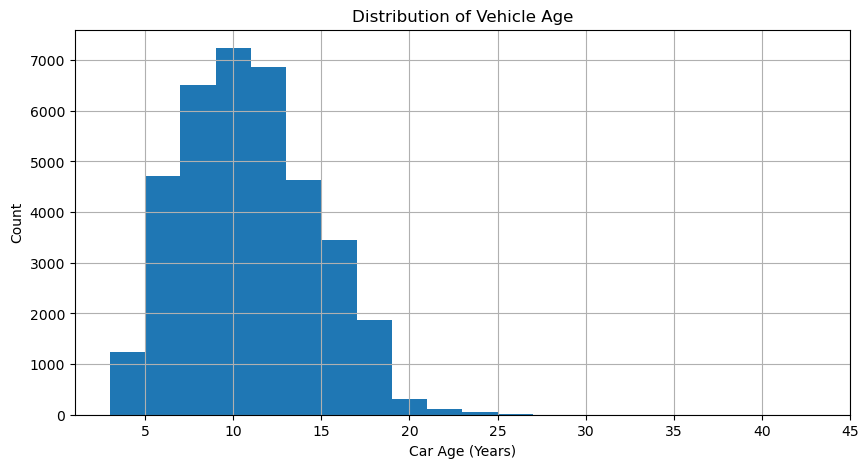

In [5]:
# ==========================================
# STEP 5 : Verify Car Age
# ==========================================

print(df["car_age"].describe())

plt.figure(figsize=(10,5))

plt.hist(
    df["car_age"],
    bins=20
)

plt.title("Distribution of Vehicle Age")

plt.xlabel("Car Age (Years)")

plt.ylabel("Count")

plt.grid(True)

plt.show()

In [6]:
# ==========================================
# STEP 6 : Create Premium Brand Feature
# ==========================================

premium_brands = [
    "bmw",
    "audi",
    "mercedes-benz",
    "jaguar",
    "jeep",
    "land rover",
    "volvo",
    "lexus",
    "mini"
]

df["premium_brand"] = (
    df["oem"]
    .isin(premium_brands)
    .astype(int)
)

df[["oem", "premium_brand"]].head()

,oem,premium_brand
0,maruti,0
1,maruti,0
2,honda,0
3,maruti,0
4,maruti,0


In [7]:
# ==========================================
# STEP 7 : Create Price Category
# ==========================================

def price_category(price):

    if price < 300000:
        return "Budget"

    elif price < 800000:
        return "Mid Range"

    elif price < 1500000:
        return "Premium"

    else:
        return "Luxury"


df["price_category"] = df["listed_price"].apply(
    price_category
)

df["price_category"].value_counts()

price_category
Mid Range    18665
Budget        7976
Premium       6599
Luxury        3766
Name: count, dtype: int64

In [8]:
# ==========================================
# STEP 8 : Save Feature Engineered Dataset
# ==========================================

df.to_csv(
    "../data/vehicle_feature_engineered.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!
